# Pandas 

https://pandas.pydata.org/docs/user_guide/dsintro.html


The `numpy` module is excellent for numerical computations, but to handle missing data or arrays with mixed types takes more work. The `pandas` module is currently the most widely used tool for data manipulation, providing high-performance, easy-to-use data structures and advanced data analysis tools.

Pandas helps you work with table-shaped data in Python. 

In particular `pandas` features:

* A fast and efficient "DataFrame" object for data manipulation with integrated indexing;
* Tools for reading and writing data between in-memory data structures and different formats (CSV, Excel, SQL, HDF5);
* Intelligent data alignment and integrated handling of missing data;
* Intelligent label-based slicing, fancy indexing, and subsetting of large data sets;
* Aggregating or transforming data with a powerful "group-by" engine; 
* High performance merging and joining of data sets;
* Hierarchical axis indexing provides an intuitive way of working with high-dimensional data in a lower-dimensional data structure;
* Time series-functionalities;
* Highly optimized for performance, with critical code paths written in Cython or C.



## 1. Setup

The usual alias for pandas is `pd`. NumPy gives us the standard missing value, `np.nan`.

In [4]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

## 2. Series: one labeled column

A `Series` is a one-dimensional collection with an index and it is capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.).. It is the building block of a DataFrame column. Sintax:

```python
s = pd.Series(data, index=index)
```

In [10]:
#### From list ####

ratings = pd.Series(
    [4.8, 4.2, 4.6],
    index=["The Blue Door", "Small Planets", "River Notes"],
    name="rating",
)
print(ratings.index)  # print index
print('Values: ',ratings.values)  # print values
print(ratings)        # print series

Index(['The Blue Door', 'Small Planets', 'River Notes'], dtype='object')
Values:  [4.8 4.2 4.6]
The Blue Door    4.8
Small Planets    4.2
River Notes      4.6
Name: rating, dtype: float64


In [23]:
print(ratings["Small Planets"])  # select by label
print("\n")
print(ratings.iloc[0])          # select by position
print("\n")
print(ratings.mean())           # calculate a summary

4.2


4.8


4.533333333333333


In [28]:
# Extracting elements and operations: same as numpy array
print (ratings[:3],'\n')
print (ratings[2:], '\n')
print (ratings[::3], '\n')
print (ratings[ratings>4.2], '\n')
print (np.exp(ratings), '\n')
print (np.mean(ratings), np.std(ratings), '\n')

The Blue Door    4.8
Small Planets    4.2
River Notes      4.6
Name: rating, dtype: float64 

River Notes    4.6
Name: rating, dtype: float64 

The Blue Door    4.8
Name: rating, dtype: float64 

The Blue Door    4.8
River Notes      4.6
Name: rating, dtype: float64 

The Blue Door    121.510418
Small Planets     66.686331
River Notes       99.484316
Name: rating, dtype: float64 

4.533333333333333 0.24944382578492927 



In [ ]:
# Try it: Create a Series named `prices` with three book titles as its index, then find its maximum.
# @ your solution here ...

In [14]:
#### From ndarray ####
# NB: index must be the same length as data

s = pd.Series(np.random.randn(5), index=["a", "b", "c", "d", "e"]) 
s

a   -1.899732
b   -0.365359
c    2.158701
d   -0.081223
e   -0.866504
dtype: float64

In [13]:
#### From dict ####
d = {"b": 1, "a": 0, "c": 2}

pd.Series(d)


b    1
a    0
c    2
dtype: int64

### Time series

Time series are very often used to profile the behaviour of a quantity as a function of time. Pandas has a special index for that, `DatetimeIndex`, that can be created e.g. with the function `pd.data_range()`

In [29]:
# to define a date, the datetime module is very useful
import datetime as dt
date = dt.date.today()
print(date)

date = dt.datetime(2022,11,30,10,45,10,15)
print (date)

# otherwise, several notations are interpreted too
date = 'Nov 30 2022'
# or alternatively
date = '30/11/2022 10:45:00'
print (date)

days = pd.date_range(date, periods=7, freq='D')
print (days)

seconds = pd.date_range(date, periods=3600, freq='s')
print (seconds)


2026-08-07
2022-11-30 10:45:10.000015
30/11/2022 10:45:00
DatetimeIndex(['2022-11-30 10:45:00', '2022-12-01 10:45:00',
               '2022-12-02 10:45:00', '2022-12-03 10:45:00',
               '2022-12-04 10:45:00', '2022-12-05 10:45:00',
               '2022-12-06 10:45:00'],
              dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2022-11-30 10:45:00', '2022-11-30 10:45:01',
               '2022-11-30 10:45:02', '2022-11-30 10:45:03',
               '2022-11-30 10:45:04', '2022-11-30 10:45:05',
               '2022-11-30 10:45:06', '2022-11-30 10:45:07',
               '2022-11-30 10:45:08', '2022-11-30 10:45:09',
               ...
               '2022-11-30 11:44:50', '2022-11-30 11:44:51',
               '2022-11-30 11:44:52', '2022-11-30 11:44:53',
               '2022-11-30 11:44:54', '2022-11-30 11:44:55',
               '2022-11-30 11:44:56', '2022-11-30 11:44:57',
               '2022-11-30 11:44:58', '2022-11-30 11:44:59'],
              dtype='datetime64[ns]', leng


Timestamped data is the most basic type of time series data that associates values with points in time. For pandas objects it means using the points in time.

functions like `pd.to_datetime` can be used, for instance, when reading information as string from a dataset.

Timestamp is the pandas equivalent of python’s Datetime and is interchangeable with it in most cases. 

In [30]:
tstamp = pd.Timestamp(dt.datetime(2020, 11, 9))

# internally it counts the nanoseconds from January 1st 19
#tstamp = pd.Timestamp(dt.datetime(1970, 1, 1, 0, 0, 0, 1))
print(tstamp.value)

# when creating a timestamp the format can be explicitly passed
ts = pd.to_datetime('2010/11/12', format='%Y/%m/%d')
print (type(ts))
print (ts.value)
ts = pd.to_datetime('12-11-2010 00:00', format='%d-%m-%Y %H:%M')
print (ts)
print (ts.value)



1604880000000000000
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
1289520000000000000
2010-11-12 00:00:00
1289520000000000000


`pd.to_datetime` can also be used to create a `DatetimeIndex`:

In [34]:
pd.to_datetime([1, 2, 3, 4], unit='D', origin=pd.Timestamp('1980-02-03'))

DatetimeIndex(['1980-02-04', '1980-02-05', '1980-02-06', '1980-02-07'], dtype='datetime64[ns]', freq=None)

A standard series can be created and (range of) elements can be used as indexes

In [32]:
tseries = pd.Series(np.random.normal(10, 1, len(days)), index=days)
# Extracting elements
print (tseries[0:4], '\n')
print (tseries['2022-11-30':'2022-12-01'], '\n') # Note - includes end time


2022-11-30 10:45:00     9.827458
2022-12-01 10:45:00    11.045511
2022-12-02 10:45:00     9.009226
2022-12-03 10:45:00     8.756259
Freq: D, dtype: float64 

2022-11-30 10:45:00     9.827458
2022-12-01 10:45:00    11.045511
Freq: D, dtype: float64 



## 3. DataFrames: complete tables

A `DataFrame` has rows and named columns. It is a 2-dimensional labeled data structure with columns of potentially different types. Like Series, DataFrame accepts many different kinds of input:

   * Dict of 1D ndarrays, lists, dicts, or Series

   * 2-D numpy.ndarray

   * Structured or record ndarray

   * A Series

   * Another DataFrame

A dictionary is a simple way to create one.

In [19]:
#### From dict ####

books = pd.DataFrame({
    "book_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "title": ["The Blue Door", "Small Planets", "River Notes", "Quiet Maps",
              "Morning Code", "Paper Bridges", "Wild Gardens", "Last Light"],
    "genre": ["Fiction", "Science", "Fiction", "Travel", "Technology", "Fiction", "Nature", "Travel"],
    "price": [12.50, 18.00, 11.00, 16.50, 24.00, 14.00, 19.50, 15.00],
    "copies_sold": [34, 18, 41, 12, 27, 22, np.nan, 15],
    "published": ["2023-02-14", "2022-09-01", "2024-01-20", "2021-06-11",
                  "2023-11-05", "2022-03-17", "2024-04-09", "2021-12-02"],
})
books

,book_id,title,genre,price,copies_sold,published
0,101,The Blue Door,Fiction,12.5,34.0,2023-02-14
1,102,Small Planets,Science,18.0,18.0,2022-09-01
2,103,River Notes,Fiction,11.0,41.0,2024-01-20
3,104,Quiet Maps,Travel,16.5,12.0,2021-06-11
4,105,Morning Code,Technology,24.0,27.0,2023-11-05
5,106,Paper Bridges,Fiction,14.0,22.0,2022-03-17
6,107,Wild Gardens,Nature,19.5,NaN,2024-04-09
7,108,Last Light,Travel,15.0,15.0,2021-12-02


In [20]:
books.head(3)

,book_id,title,genre,price,copies_sold,published
0,101,The Blue Door,Fiction,12.5,34.0,2023-02-14
1,102,Small Planets,Science,18.0,18.0,2022-09-01
2,103,River Notes,Fiction,11.0,41.0,2024-01-20


In [21]:
print("Shape:", books.shape)       # (rows, columns)
print("Columns:", books.columns.tolist())
books.info()                         # column types and missing values

Shape: (8, 6)
Columns: ['book_id', 'title', 'genre', 'price', 'copies_sold', 'published']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   book_id      8 non-null      int64  
 1   title        8 non-null      object 
 2   genre        8 non-null      object 
 3   price        8 non-null      float64
 4   copies_sold  7 non-null      float64
 5   published    8 non-null      object 
dtypes: float64(2), int64(1), object(3)
memory usage: 512.0+ bytes


In [22]:
books.describe(include="all")

,book_id,title,genre,price,copies_sold,published
count,8.00000,8,8,8.000000,7.000000,8
unique,NaN,8,5,NaN,NaN,8
top,NaN,The Blue Door,Fiction,NaN,NaN,2023-02-14
freq,NaN,1,3,NaN,NaN,1
mean,104.50000,NaN,NaN,16.312500,24.142857,NaN
std,2.44949,NaN,NaN,4.174219,10.510765,NaN
min,101.00000,NaN,NaN,11.000000,12.000000,NaN
25%,102.75000,NaN,NaN,13.625000,16.500000,NaN
50%,104.50000,NaN,NaN,15.750000,22.000000,NaN
75%,106.25000,NaN,NaN,18.375000,30.500000,NaN


In [ ]:
# Try it: Show the last two rows, then check the number of rows and columns.
# @ your solution here ...

## 4. Selecting rows and columns

Use brackets for columns, `.loc` for labels, and `.iloc` for integer positions.

In [35]:
books["title"]                    # one column: Series

0    The Blue Door
1    Small Planets
2      River Notes
3       Quiet Maps
4     Morning Code
5    Paper Bridges
6     Wild Gardens
7       Last Light
Name: title, dtype: object

In [36]:
books[["title", "price"]]         # several columns: DataFrame

,title,price
0,The Blue Door,12.5
1,Small Planets,18.0
2,River Notes,11.0
3,Quiet Maps,16.5
4,Morning Code,24.0
5,Paper Bridges,14.0
6,Wild Gardens,19.5
7,Last Light,15.0


In [37]:
books.loc[1:3, ["title", "genre"]]  # labels; the end label is included

,title,genre
1,Small Planets,Science
2,River Notes,Fiction
3,Quiet Maps,Travel


In [38]:
books.iloc[1:4, 1:4]               # positions; the end position is excluded

,title,genre,price
1,Small Planets,Science,18.0
2,River Notes,Fiction,11.0
3,Quiet Maps,Travel,16.5


In [39]:
print(books.at[0, "title"])        # one value by labels
print(books.iat[0, 1])             # one value by positions

The Blue Door
The Blue Door


In [ ]:
# Try it: Select the first four rows and only the `title` and `copies_sold` columns.
# @ your solution here ...

## 5. Filtering and sorting

A condition creates `True`/`False` values. Put it inside `.loc` to keep matching rows. Use `&`, `|`, and `~` for and, or, and not; wrap each condition in parentheses.

In [40]:
books.loc[books["price"] < 16, ["title", "price"]]

,title,price
0,The Blue Door,12.5
2,River Notes,11.0
5,Paper Bridges,14.0
7,Last Light,15.0


In [100]:
books[books["price"] < 13]

,book_id,title,genre,price,copies_sold,published,revenue,price_band,copies_sold_filled,title_lower,title_words,published_year,published_month
0,101,The Blue Door,Fiction,12.5,34.0,2023-02-14,425.0,budget,34.0,the blue door,3,2023,2
2,103,River Notes,Fiction,11.0,41.0,2024-01-20,451.0,budget,41.0,river notes,2,2024,1


In [41]:
books.loc[
    (books["genre"] == "Fiction") & (books["copies_sold"] >= 25),
    ["title", "copies_sold"],
]

,title,copies_sold
0,The Blue Door,34.0
2,River Notes,41.0


In [42]:
books.loc[books["genre"].isin(["Travel", "Nature"])]

,book_id,title,genre,price,copies_sold,published
3,104,Quiet Maps,Travel,16.5,12.0,2021-06-11
6,107,Wild Gardens,Nature,19.5,NaN,2024-04-09
7,108,Last Light,Travel,15.0,15.0,2021-12-02


In [43]:
books.sort_values(["genre", "price"], ascending=[True, False])

,book_id,title,genre,price,copies_sold,published
5,106,Paper Bridges,Fiction,14.0,22.0,2022-03-17
0,101,The Blue Door,Fiction,12.5,34.0,2023-02-14
2,103,River Notes,Fiction,11.0,41.0,2024-01-20
6,107,Wild Gardens,Nature,19.5,NaN,2024-04-09
1,102,Small Planets,Science,18.0,18.0,2022-09-01
4,105,Morning Code,Technology,24.0,27.0,2023-11-05
3,104,Quiet Maps,Travel,16.5,12.0,2021-06-11
7,108,Last Light,Travel,15.0,15.0,2021-12-02


In [ ]:
# Try it: Find books that cost at least 15 and are not Fiction. Sort them from cheapest to most expensive.
# @ your solution here ...

## 6. Adding, changing, and removing data

Column operations work on every row at once. This is usually clearer and faster than a Python loop.

In [44]:
books["revenue"] = books["price"] * books["copies_sold"]
books["price_band"] = np.where(books["price"] < 15, "budget", "standard")
books.head()

,book_id,title,genre,price,copies_sold,published,revenue,price_band
0,101,The Blue Door,Fiction,12.5,34.0,2023-02-14,425.0,budget
1,102,Small Planets,Science,18.0,18.0,2022-09-01,324.0,standard
2,103,River Notes,Fiction,11.0,41.0,2024-01-20,451.0,budget
3,104,Quiet Maps,Travel,16.5,12.0,2021-06-11,198.0,standard
4,105,Morning Code,Technology,24.0,27.0,2023-11-05,648.0,standard


In [45]:
edited_books = books.rename(columns={"copies_sold": "units"})
edited_books = edited_books.drop(columns="price_band")
edited_books.head(2)

,book_id,title,genre,price,units,published,revenue
0,101,The Blue Door,Fiction,12.5,34.0,2023-02-14,425.0
1,102,Small Planets,Science,18.0,18.0,2022-09-01,324.0


Most pandas methods return a new object. Assign the result when you want to keep it. Use `.copy()` before changing a filtered table.

In [46]:
fiction = books.loc[books["genre"] == "Fiction"].copy()
fiction["price"] = fiction["price"] * 0.90
fiction

,book_id,title,genre,price,copies_sold,published,revenue,price_band
0,101,The Blue Door,Fiction,11.25,34.0,2023-02-14,425.0,budget
2,103,River Notes,Fiction,9.90,41.0,2024-01-20,451.0,budget
5,106,Paper Bridges,Fiction,12.60,22.0,2022-03-17,308.0,budget


In [ ]:
# Try it: Add a `discount_price` column equal to 80% of `price`, then remove it.
# @ your solution here ...

## 7. Missing values and duplicates

Real data is often incomplete. First locate missing values, then choose whether to fill or remove them. The right choice depends on what the data means.

In [47]:
books.isna().sum()

book_id        0
title          0
genre          0
price          0
copies_sold    1
published      0
revenue        1
price_band     0
dtype: int64

In [50]:
books["copies_sold_filled"] = books["copies_sold"].fillna(0)
books[["title", "copies_sold", "copies_sold_filled"]]

,title,copies_sold,copies_sold_filled
0,The Blue Door,34.0,34.0
1,Small Planets,18.0,18.0
2,River Notes,41.0,41.0
3,Quiet Maps,12.0,12.0
4,Morning Code,27.0,27.0
5,Paper Bridges,22.0,22.0
6,Wild Gardens,NaN,0.0
7,Last Light,15.0,15.0


In [51]:
complete_sales = books.dropna(subset=["copies_sold"])
complete_sales.shape

(7, 9)

In [58]:
repeated = pd.concat([books, books.iloc[[0]]], ignore_index=True)
print("Duplicate rows:", repeated.duplicated().sum())
repeated = repeated.drop_duplicates()
print("Rows after cleanup:", len(repeated))

Duplicate rows: 1
Rows after cleanup: 8


In [ ]:
# Try it: Find the row with missing sales. Make a new DataFrame where missing sales use the median instead.
# @ your solution here ...

## 8. Data types, text, and dates

Correct types make data easier to calculate and filter. String and datetime columns have useful `.str` and `.dt` tools.

In [59]:
books["published"] = pd.to_datetime(books["published"])
books["book_id"] = books["book_id"].astype("string")
books.dtypes

book_id               string[python]
title                         object
genre                         object
price                        float64
copies_sold                  float64
published             datetime64[ns]
revenue                      float64
price_band                    object
copies_sold_filled           float64
dtype: object

In [88]:
books['published'].dt.year       # anno
books['published'].dt.month      # mese
books['published'].dt.day        # giorno
books['published'].dt.day_name() # nome del giorno
books['published'].dt.month_name() # nome del mese

0     February
1    September
2      January
3         June
4     November
5        March
6        April
7     December
Name: published, dtype: object

In [60]:
books["title_lower"] = books["title"].str.lower()
books["title_words"] = books["title"].str.split().str.len()
books[["title", "title_lower", "title_words"]].head()

,title,title_lower,title_words
0,The Blue Door,the blue door,3
1,Small Planets,small planets,2
2,River Notes,river notes,2
3,Quiet Maps,quiet maps,2
4,Morning Code,morning code,2


In [61]:
books["published_year"] = books["published"].dt.year
books.loc[books["title"].str.contains("light|morning", case=False), ["title", "published_year"]]

,title,published_year
4,Morning Code,2023
7,Last Light,2021


In [ ]:
# Try it: Create a `published_month` column, then find titles containing the word `the` (ignore case).
# @ your solution here ...

In [74]:
books['published_month'] = books['published'].dt.month

In [92]:
books[ 'title'].str.find('The')

0    0
1   -1
2   -1
3   -1
4   -1
5   -1
6   -1
7   -1
Name: title, dtype: int64

In [93]:
books['title'].str.split().str.get(0)

0        The
1      Small
2      River
3      Quiet
4    Morning
5      Paper
6       Wild
7       Last
Name: title, dtype: object

## 9. Summary statistics and grouping

Use simple methods for a quick answer. Use `groupby` to split rows into groups and summarize each group.

In [94]:
print("Mean price:", books["price"].mean())
print("Most common genre:", books["genre"].mode().iat[0])
books["genre"].value_counts()

Mean price: 16.3125
Most common genre: Fiction


genre
Fiction       3
Travel        2
Science       1
Technology    1
Nature        1
Name: count, dtype: int64

In [96]:
# stampa la media dei prezzi raggruppati per genere e li ordina in modo decrescente
books.groupby("genre")["price"].mean().sort_values(ascending=False) 

genre
Technology    24.00
Nature        19.50
Science       18.00
Travel        15.75
Fiction       12.50
Name: price, dtype: float64

In [98]:
#.agg() = "per ogni gruppo, applica queste funzioni di aggregazione"
# dopo il groupby, permette di calcolare più statistiche contemporaneamente.
genre_summary = (
    books.groupby("genre", as_index=False)
         .agg(
             number_of_books=("book_id", "count"),
             average_price=("price", "mean"),
             total_sales=("copies_sold", "sum"),
         )
)
genre_summary

,genre,number_of_books,average_price,total_sales
0,Fiction,3,12.50,97.0
1,Nature,1,19.50,0.0
2,Science,1,18.00,18.0
3,Technology,1,24.00,27.0
4,Travel,2,15.75,27.0


In [ ]:
# Try it: Group by `published_year` and calculate the number of books and average price for each year.
# @ your solution here ...

## 10. Pivot tables

A pivot table puts one category on the rows and another on the columns. It is a compact way to compare groups.

In [101]:
books["sales_level"] = np.where(books["copies_sold_filled"] >= 25, "high", "low")
pd.pivot_table(
    books,
    index="genre",
    columns="sales_level",
    values="book_id",
    aggfunc="count",
    fill_value=0,
)

sales_level,high,low
genre,,
Fiction,2,1
Nature,0,1
Science,0,1
Technology,1,0
Travel,0,2


In [ ]:
# Try it: Build a pivot table with `published_year` as rows, `genre` as columns, and mean `price` as values.
# @ your solution here ...

## 11. Combining tables

Use `concat` to stack similar tables. Use `merge` to match information using a shared key.

In [103]:
stock = pd.DataFrame({
    "book_id": ["101", "102", "103", "104", "105", "106", "107", "108"],
    "in_stock": [7, 3, 9, 2, 5, 0, 6, 4],
    "supplier": ["North", "East", "North", "West", "East", "West", "North", "West"],
})

book_details = books.merge(stock, on="book_id", how="left")
book_details[["title", "in_stock", "supplier"]]

,title,in_stock,supplier
0,The Blue Door,7,North
1,Small Planets,3,East
2,River Notes,9,North
3,Quiet Maps,2,West
4,Morning Code,5,East
5,Paper Bridges,0,West
6,Wild Gardens,6,North
7,Last Light,4,West


In [105]:
first_half = books.iloc[:4]
second_half = books.iloc[4:]
combined = pd.concat([first_half, second_half], ignore_index=True)
combined.shape

(8, 14)

Common merge choices: `inner` keeps matches, `left` keeps every left row, and `outer` keeps every row from both tables.

In [ ]:
# Try it: Create a small DataFrame with `supplier` and `city`, then merge it into `book_details`.
# @ your solution here ...

## 12. Reading and saving files

CSV is common and works everywhere. `index=False` avoids saving the DataFrame index as an extra column.

In [106]:
from io import StringIO

csv_text = """title,price
Cloud Atlas,13.5
Open Roads,17.0
"""
new_books = pd.read_csv(StringIO(csv_text))
new_books

,title,price
0,Cloud Atlas,13.5
1,Open Roads,17.0


In [ ]:
# Save when you are ready:
# books.to_csv("clean_books.csv", index=False)

# Other useful readers:
# pd.read_excel("books.xlsx", sheet_name="Sheet1")
# pd.read_parquet("books.parquet")

In [ ]:
# Try it: Save `genre_summary` to `genre_summary.csv` without the index, then read it back.
# @ your solution here ...

## 13. Simple plots

Pandas can create quick plots. The plot uses Matplotlib underneath.

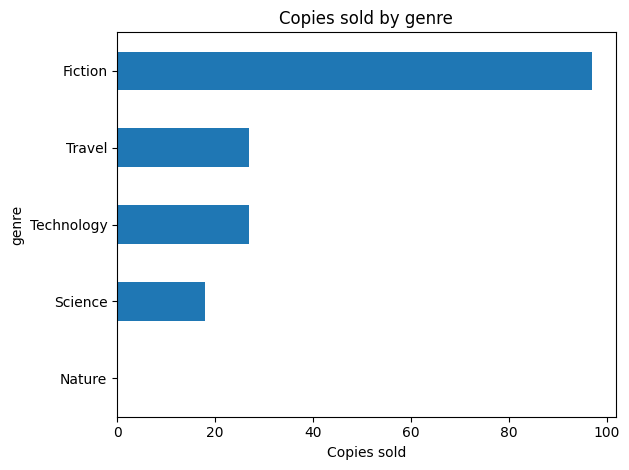

In [107]:
import matplotlib.pyplot as plt

books.groupby("genre")["copies_sold"].sum().sort_values().plot(
    kind="barh", title="Copies sold by genre", xlabel="Copies sold"
)
plt.tight_layout()
plt.show()

In [ ]:
# Try it: Make a bar chart of average price by genre. Add a clear title.
# @ your solution here ...

## 14. A practical workflow

Most pandas tasks follow the same pattern: load, inspect, clean, transform, analyze, and save. Keep each step small and check the result.

In [108]:
final_report = (
    book_details
    .dropna(subset=["copies_sold"])
    .assign(revenue=lambda data: data["price"] * data["copies_sold"])
    .groupby("supplier", as_index=False)
    .agg(total_revenue=("revenue", "sum"), books=("book_id", "count"))
    .sort_values("total_revenue", ascending=False)
)
final_report

,supplier,total_revenue,books
0,East,972.0,2
1,North,876.0,2
2,West,731.0,3


In [ ]:
# Try it: Create a report with one row per genre showing total revenue, average price, and total stock. Sort by total revenue.
# @ your solution here ...

## Keep practicing

You now know the core pandas workflow. When you meet a new dataset, begin with `head()`, `shape`, `info()`, and missing-value counts. Then ask one small question at a time and build from there.

Useful next topics are reshaping with `melt`, time-series resampling, rolling calculations, and larger datasets—but the tools in this notebook cover most everyday beginner tasks.